Mini-Project: Predicting Heart Disease Using Logistic Regression


👩‍🏫 👩🏿‍🏫 What You’ll learn

    How to handle real-world healthcare data.
    Preprocessing data: Handling missing values, categorical variables, and feature scaling.
    Training a logistic regression model to predict the presence of heart disease.
    Evaluating the model’s performance using accuracy, precision, recall, and the F1 score.


💼 Tools and Libraries Required

    Python: A popular programming language for data analysis and machine learning.
    scikit-learn: Provides tools for data mining and data analysis, including logistic regression.
    pandas: For data manipulation and analysis.
    matplotlib and seaborn: For data visualization.
    Jupyter Notebook or any Python IDE.


Task

Your task is to use the Heart Disease UCI dataset to predict whether or not a patient has heart disease based on various medical attributes.

1. Data Preparation:

    Download the “Heart Disease UCI” dataset.
    Perform exploratory data analysis (EDA) to understand the dataset.
    Preprocess the data: handle missing values if any, encode categorical variables, and scale the features.

2. Model Training:

    Split the dataset into a training set and a testing set.
    Train a logistic regression model on the training set.

3. Model Evaluation:

    Evaluate the model on the testing set using accuracy, precision, recall, and F1 score.
    Use a confusion matrix to visualize the model’s performance.


Expected Deliverables

A Jupyter Notebook containing:

    The EDA and preprocessing steps.
    The code for training and evaluating the logistic regression model.
    A confusion matrix and classification report for model evaluation.
    Any visualizations that helped you understand the dataset and the model’s performance.




In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error, classification_report, roc_auc_score, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

In [2]:
# "1. Data Preparation:

#     Download the “Heart Disease UCI” dataset.
#     Perform exploratory data analysis (EDA) to understand the dataset.
#     Preprocess the data: handle missing values if any, encode categorical variables, and scale the features."
df = pd.read_csv('heart_disease_uci.csv')
print(f'df shape: {df.shape}')
display(df.info())
display(df.head())
display(df.describe())


df shape: (920, 16)
<class 'pandas.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        920 non-null    int64  
 1   age       920 non-null    int64  
 2   sex       920 non-null    str    
 3   dataset   920 non-null    str    
 4   cp        920 non-null    str    
 5   trestbps  861 non-null    float64
 6   chol      890 non-null    float64
 7   fbs       830 non-null    object 
 8   restecg   918 non-null    str    
 9   thalch    865 non-null    float64
 10  exang     865 non-null    object 
 11  oldpeak   858 non-null    float64
 12  slope     611 non-null    str    
 13  ca        309 non-null    float64
 14  thal      434 non-null    str    
 15  num       920 non-null    int64  
dtypes: float64(5), int64(3), object(2), str(6)
memory usage: 115.1+ KB


None

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


,id,age,trestbps,chol,thalch,oldpeak,ca,num
count,920.000000,920.000000,861.000000,890.000000,865.000000,858.000000,309.000000,920.000000
mean,460.500000,53.510870,132.132404,199.130337,137.545665,0.878788,0.676375,0.995652
std,265.725422,9.424685,19.066070,110.780810,25.926276,1.091226,0.935653,1.142693
min,1.000000,28.000000,0.000000,0.000000,60.000000,-2.600000,0.000000,0.000000
25%,230.750000,47.000000,120.000000,175.000000,120.000000,0.000000,0.000000,0.000000
50%,460.500000,54.000000,130.000000,223.000000,140.000000,0.500000,0.000000,1.000000
75%,690.250000,60.000000,140.000000,268.000000,157.000000,1.500000,1.000000,2.000000
max,920.000000,77.000000,200.000000,603.000000,202.000000,6.200000,3.000000,4.000000


In [3]:
# Checking values of categorical values:
for col in ['sex','dataset','cp','fbs','restecg','slope','thal']:
    display(df[col].value_counts())

sex
Male      726
Female    194
Name: count, dtype: int64

dataset
Cleveland        304
Hungary          293
VA Long Beach    200
Switzerland      123
Name: count, dtype: int64

cp
asymptomatic       496
non-anginal        204
atypical angina    174
typical angina      46
Name: count, dtype: int64

fbs
False    692
True     138
Name: count, dtype: int64

restecg
normal              551
lv hypertrophy      188
st-t abnormality    179
Name: count, dtype: int64

slope
flat           345
upsloping      203
downsloping     63
Name: count, dtype: int64

thal
normal               196
reversable defect    192
fixed defect          46
Name: count, dtype: int64

In [4]:
# When I create X and y for the model, I will exclude irrelevant variables: id, dataset (where data comes from should not be a parameter for predicting heart disease).
# I will exclude num from X to use as y
# I will encode all T/F and gender as binary: sex, fbs, exang
# I think I should encode cp, restecg, and thal as one-hot encoding.

In [5]:
df.isna().sum()

id            0
age           0
sex           0
dataset       0
cp            0
trestbps     59
chol         30
fbs          90
restecg       2
thalch       55
exang        55
oldpeak      62
slope       309
ca          611
thal        486
num           0
dtype: int64

In [6]:
# Calculate the percentage of missing values per column
missing_props = df.isnull().mean()
print("Proportion of missing values per column:")
print(missing_props[missing_props > 0].sort_values(ascending=False))

Proportion of missing values per column:
ca          0.664130
thal        0.528261
slope       0.335870
fbs         0.097826
oldpeak     0.067391
trestbps    0.064130
exang       0.059783
thalch      0.059783
chol        0.032609
restecg     0.002174
dtype: float64


In [7]:
# Create a copy of the raw original data, but clean df to make this all easier.
df_raw = df.copy()

for col in df.columns:
    prop_missing = df[col].isnull().mean()
    
    # Over 50% missing -> Drop the column
    if prop_missing > 0.50:
        df.drop(columns=col, inplace=True)
        print(f"Dropped column '{col}' (missing: {prop_missing:.2%})")
        
    # Between 5% and 50% missing -> Impute
    elif 0.05 <= prop_missing <= 0.50:
        if df[col].dtype in ['int64', 'float64']:
            # Numerical: Median
            fill_val = df[col].median()
            df[col] = df[col].fillna(fill_val)
            print(f"Imputed '{col}' with Median (missing: {prop_missing:.2%})")
        else:
            # Categorical: Mode
            fill_val = df[col].mode()[0]
            df[col] = df[col].fillna(fill_val)
            print(f"Imputed '{col}' with Mode (missing: {prop_missing:.2%})")
            
    # Less than 5% missing (but more than 0) -> Drop rows
    elif 0 < prop_missing < 0.05:
        df.dropna(subset=[col], inplace=True)
        print(f"Dropped rows in '{col}' (missing: {prop_missing:.2%})")

# Final check
print(f"\nRemaining missing values: {df.isnull().sum().sum()}")

Imputed 'trestbps' with Median (missing: 6.41%)
Dropped rows in 'chol' (missing: 3.26%)
Imputed 'fbs' with Mode (missing: 10.11%)
Dropped rows in 'restecg' (missing: 0.22%)
Imputed 'thalch' with Median (missing: 5.86%)
Imputed 'exang' with Mode (missing: 5.86%)
Imputed 'oldpeak' with Median (missing: 6.64%)
Imputed 'slope' with Mode (missing: 32.21%)
Dropped column 'ca' (missing: 65.32%)
Dropped column 'thal' (missing: 51.35%)

Remaining missing values: 0


In [8]:
# 1. Binary Encoding (Manual Mapping)
df['sex'] = df['sex'].map({'Male': 1, 'Female': 0})
# Handle fbs and exang if they aren't already 0/1
binary_cols = ['fbs', 'exang']

for col in binary_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce').astype(int)

# 2. One-Hot Encoding for Nominal variables (CP, RestECG, Slope); Thal column dropped because of missing vals.
# We use get_dummies because they aren't strictly ordinal
df = pd.get_dummies(df, columns=['cp', 'restecg','slope'], drop_first=True)

# 3. Define X and y
# Drop irrelevant columns and the target
X = df.drop(columns=['id', 'dataset', 'num'], errors='ignore')
y = df['num']

# 4. Train/Test Split
# Use stratify=y to ensure all stages (0-4) are represented in both sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 5. Scaling (Essential for Multinomial Logistic Regression)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [9]:
# "2. Model Training:

#     Split the dataset into a training set and a testing set.
#     Train a logistic regression model on the training set."


# 'lbfgs' is a good solver for multinomial problems
model = LogisticRegression(
    solver='lbfgs', 
    max_iter=1000, 
    class_weight='balanced'
)


model.fit(X_train_scaled, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :ter

--- Classification Report ---
              precision    recall  f1-score   support

           0       0.82      0.67      0.74        79
           1       0.45      0.41      0.43        51
           2       0.36      0.18      0.24        22
           3       0.28      0.38      0.32        21
           4       0.04      0.20      0.06         5

    accuracy                           0.49       178
   macro avg       0.39      0.37      0.36       178
weighted avg       0.57      0.49      0.52       178



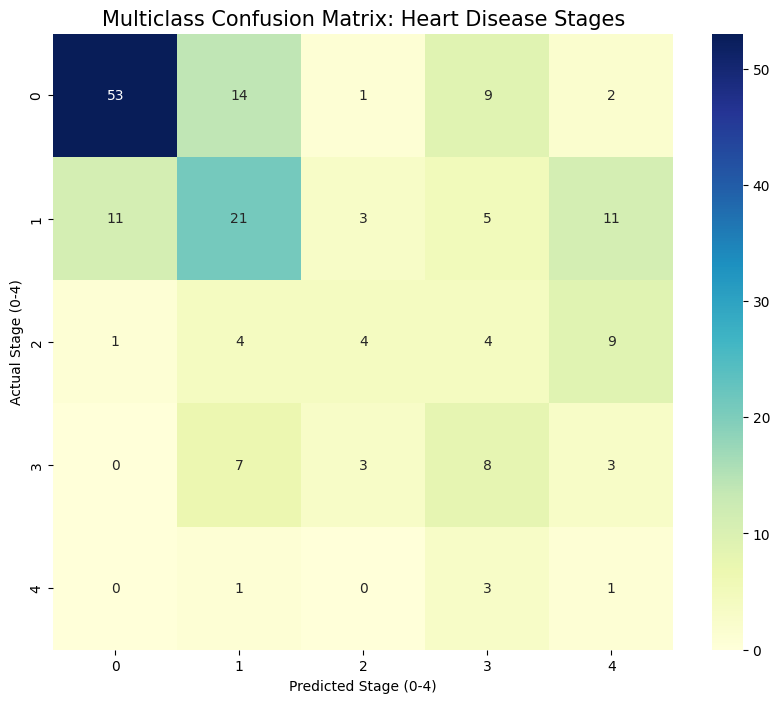

In [10]:
# "3. Model Evaluation:

#     Evaluate the model on the testing set using accuracy, precision, recall, and F1 score.
#     Use a confusion matrix to visualize the model’s performance."
y_pred = model.predict(X_test_scaled)
# Print the Classification Report
# This includes Precision, Recall, and F1-score for both classes
print("--- Classification Report ---")
print(classification_report(y_test, y_pred))

#Confusion Matrix:
# 1. Generate the confusion matrix
cm = confusion_matrix(y_test, y_pred)

# 2. Plotting the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(
    cm, 
    annot=True,          # Show the actual numbers in the boxes
    fmt='d',             # Format as integers
    cmap='YlGnBu',       # A clean color gradient
    xticklabels=[0, 1, 2, 3, 4], 
    yticklabels=[0, 1, 2, 3, 4]
)

plt.title('Multiclass Confusion Matrix: Heart Disease Stages', fontsize=15)
plt.xlabel('Predicted Stage (0-4)')
plt.ylabel('Actual Stage (0-4)')
plt.show()

Conclusion:
The results from testing this model are not very good (low accuracy, low precision and recall for most target values). This can be seen in the confusion matrix as well, with most cells being low.
This appears to be because the dataset is relatively small (920 rows before cleaning) and it may not be big enough to provide sufficient information to train a complex multiclass target model. With this size a dataset, it may be better to use a simpler binary model that can only predict whether or not there is heart disease, by converting the target value to binary (0 or 1) before training the model.